In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fact = pd.read_csv("fact_transit_trips.csv")

In [2]:
fact.isnull().sum()

TripID                0
RouteKey              0
BusKey                0
TimeKey               0
PerfKey               0
StartTime             0
EndTime               0
FuelConsumed          0
Distance              0
TargetTime            0
ActualTime            0
DelayAnalysis         0
OperatingCostPerKM    0
PassengerCount        0
EngineTemperature     0
RPM                   0
FuelRate              0
IdleDuration          0
AverageSpeed          0
BrakeEvents           0
OTPFlag               0
dtype: int64

In [3]:
fact.duplicated().sum()

np.int64(0)

In [4]:
fact.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TripID              20000 non-null  object 
 1   RouteKey            20000 non-null  int64  
 2   BusKey              20000 non-null  int64  
 3   TimeKey             20000 non-null  int64  
 4   PerfKey             20000 non-null  int64  
 5   StartTime           20000 non-null  object 
 6   EndTime             20000 non-null  object 
 7   FuelConsumed        20000 non-null  float64
 8   Distance            20000 non-null  int64  
 9   TargetTime          20000 non-null  int64  
 10  ActualTime          20000 non-null  int64  
 11  DelayAnalysis       20000 non-null  int64  
 12  OperatingCostPerKM  20000 non-null  float64
 13  PassengerCount      20000 non-null  int64  
 14  EngineTemperature   20000 non-null  float64
 15  RPM                 20000 non-null  int64  
 16  Fuel

In [5]:
fact['StartTime'] = pd.to_datetime(
    fact['StartTime'],
    dayfirst=True
)

fact['EndTime'] = pd.to_datetime(
    fact['EndTime'],
    dayfirst=True
)

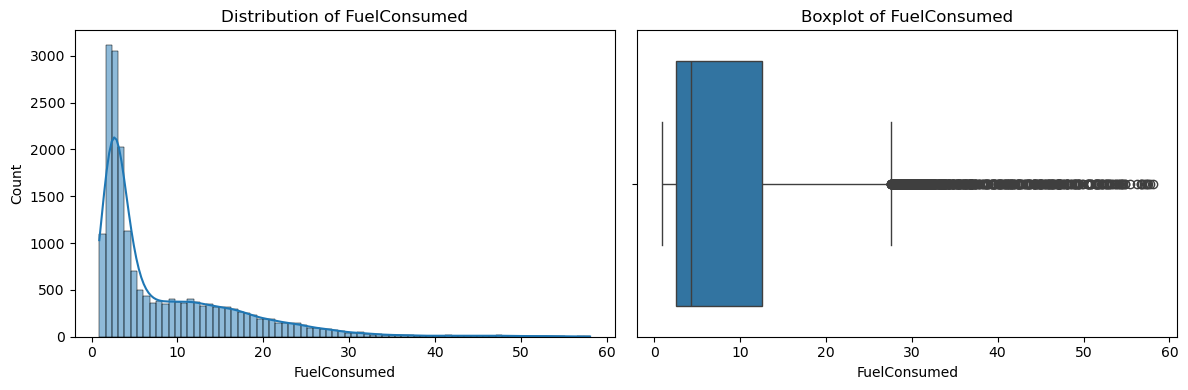

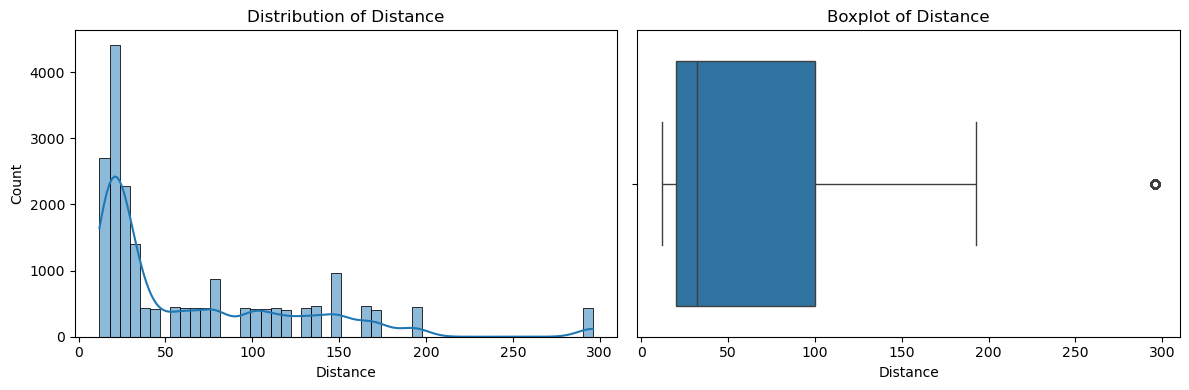

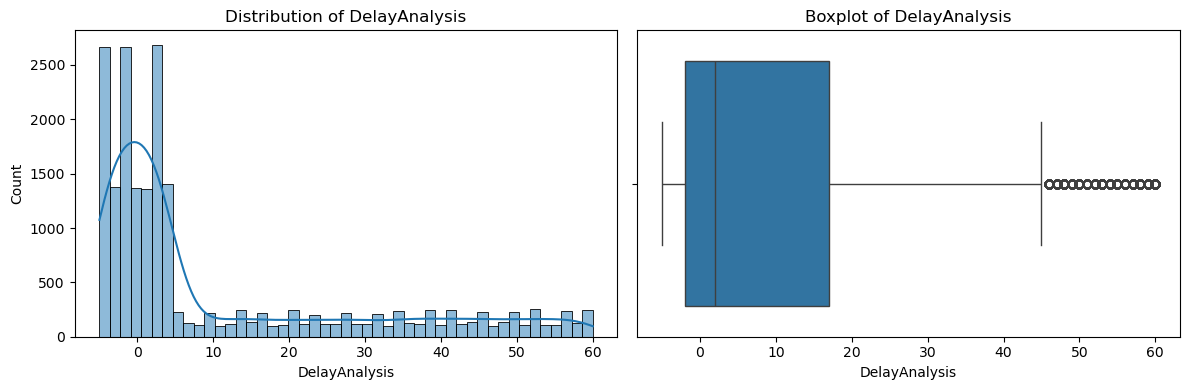

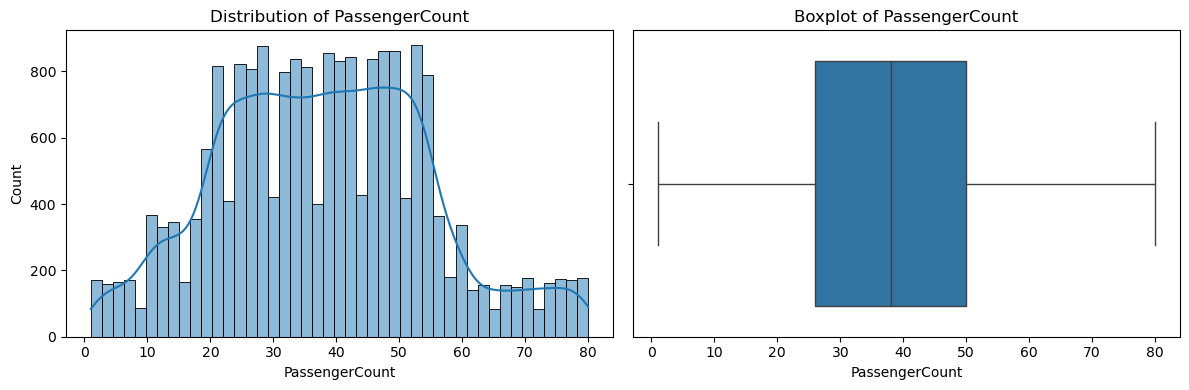

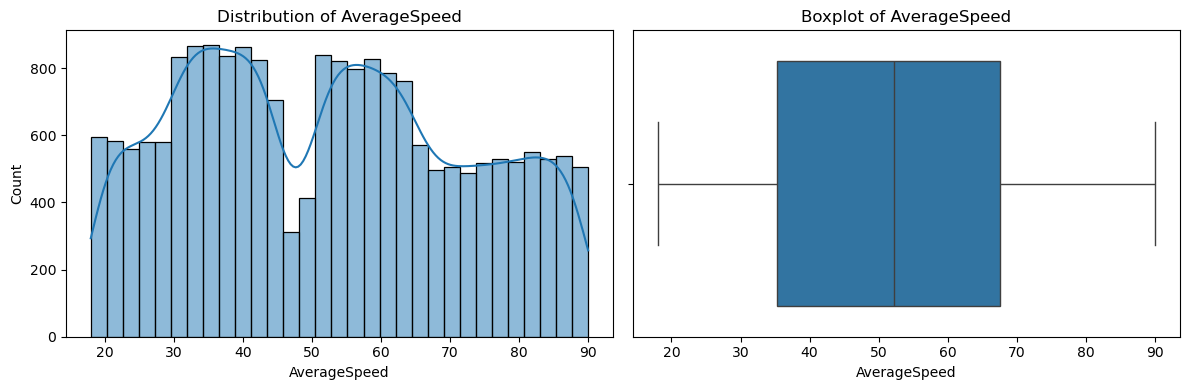

In [6]:
num_cols = [
    'FuelConsumed',
    'Distance',
    'DelayAnalysis',
    'PassengerCount',
    'AverageSpeed'
]

for col in num_cols:

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(fact[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=fact[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

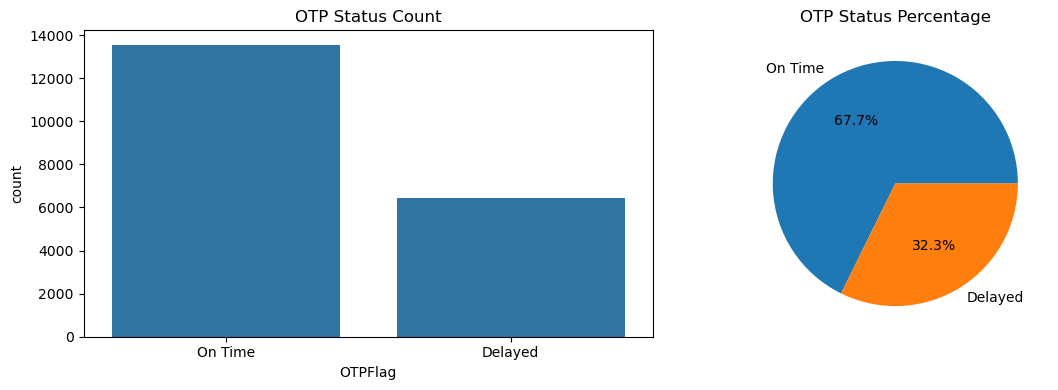

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

sns.countplot(
    x='OTPFlag',
    data=fact
)

plt.title('OTP Status Count')

plt.subplot(1,2,2)

fact['OTPFlag'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('OTP Status Percentage')

plt.tight_layout()
plt.show()

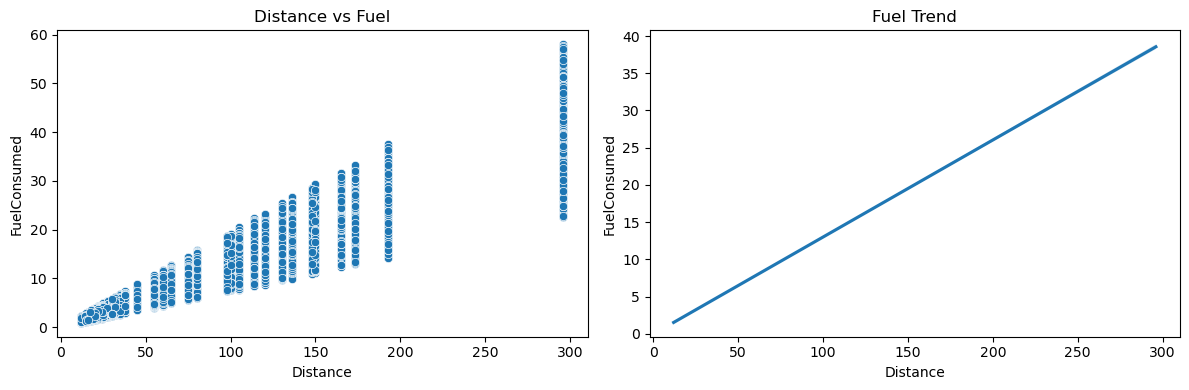

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

sns.scatterplot(
    x='Distance',
    y='FuelConsumed',
    data=fact
)

plt.title('Distance vs Fuel')

plt.subplot(1,2,2)

sns.regplot(
    x='Distance',
    y='FuelConsumed',
    data=fact,
    scatter=False
)

plt.title('Fuel Trend')

plt.tight_layout()
plt.show()

In [9]:
fact_num = fact.select_dtypes(include='number')

corr = fact_num.corr()

corr

,RouteKey,BusKey,TimeKey,PerfKey,FuelConsumed,Distance,TargetTime,ActualTime,DelayAnalysis,OperatingCostPerKM,PassengerCount,EngineTemperature,RPM,FuelRate,IdleDuration,AverageSpeed,BrakeEvents
RouteKey,1.000000,-0.002484,-0.005817,-0.009462,0.570612,0.605572,0.473994,0.405281,-0.139068,-0.009045,-0.054816,-0.000493,-0.000590,0.001325,-0.004800,0.795278,-0.011382
BusKey,-0.002484,1.000000,-0.003342,0.002738,0.004315,0.006784,0.010612,0.009182,-0.002818,0.008049,0.002328,-0.007019,-0.008592,-0.001906,-0.006262,-0.001289,-0.007087
TimeKey,-0.005817,-0.003342,1.000000,-0.007166,-0.009934,-0.008537,-0.005906,-0.006430,-0.002039,-0.008296,-0.002830,0.004249,0.007940,-0.005845,-0.005984,-0.011613,-0.001712
PerfKey,-0.009462,0.002738,-0.007166,1.000000,-0.009067,-0.011730,-0.012972,-0.006396,0.016641,-0.002904,-0.005742,-0.004356,-0.009864,-0.000632,0.019960,-0.004541,0.004804
FuelConsumed,0.570612,0.004315,-0.009934,-0.009067,1.000000,0.948566,0.888975,0.818904,-0.100096,-0.013866,-0.021151,-0.000273,-0.001749,0.228928,-0.001271,0.615364,-0.011783
Distance,0.605572,0.006784,-0.008537,-0.011730,0.948566,1.000000,0.938138,0.864321,-0.105280,-0.013449,-0.021702,-0.001194,0.000960,0.008344,-0.003521,0.649855,-0.012658
TargetTime,0.473994,0.010612,-0.005906,-0.012972,0.888975,0.938138,1.000000,0.931193,-0.085224,-0.014797,-0.010391,-0.001610,0.002260,0.006968,-0.006669,0.401254,-0.015656
ActualTime,0.405281,0.009182,-0.006430,-0.006396,0.818904,0.864321,0.931193,1.000000,0.283839,-0.012059,-0.005648,-0.001304,0.005208,0.006893,-0.006041,0.338955,-0.010346
DelayAnalysis,-0.139068,-0.002818,-0.002039,0.016641,-0.100096,-0.105280,-0.085224,0.283839,1.000000,0.005962,0.011894,0.000669,0.008289,0.000510,0.001031,-0.129015,0.012904
OperatingCostPerKM,-0.009045,0.008049,-0.008296,-0.002904,-0.013866,-0.013449,-0.014797,-0.012059,0.005962,1.000000,-0.001011,0.002533,0.002651,-0.009843,0.000353,-0.005961,0.009128


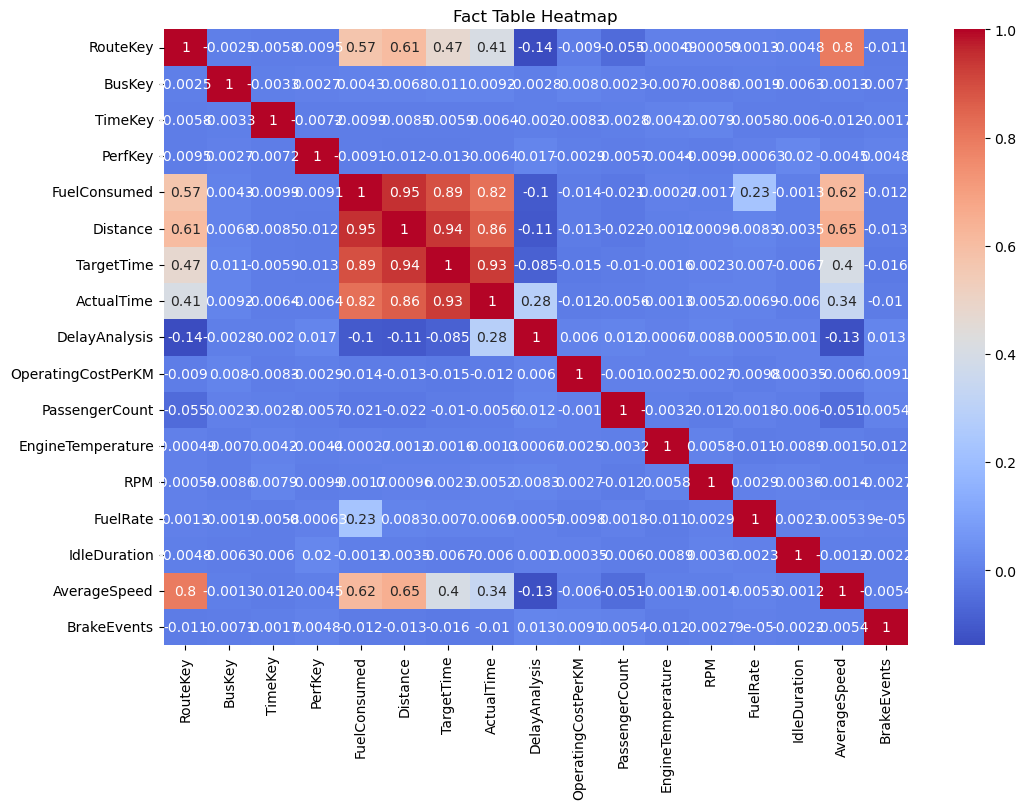

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Fact Table Heatmap')

plt.show()

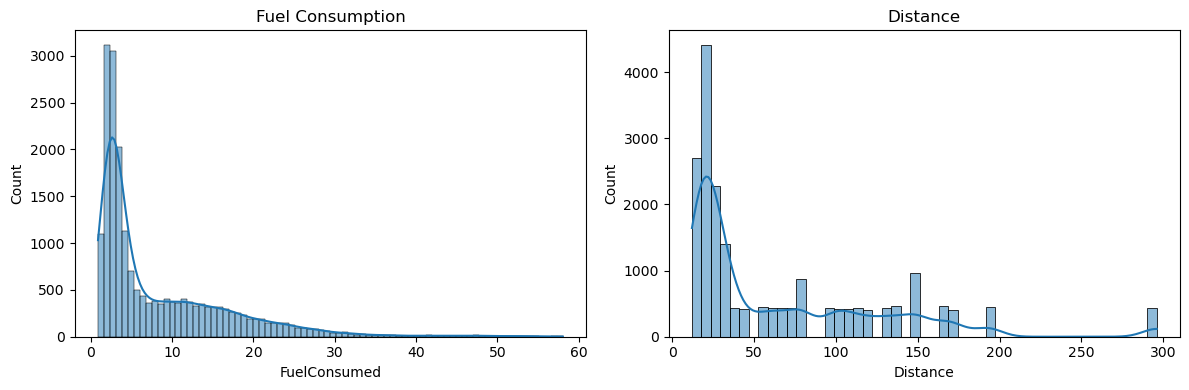

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(
    fact['FuelConsumed'],
    kde=True
)

plt.title('Fuel Consumption')

plt.subplot(1,2,2)
sns.histplot(
    fact['Distance'],
    kde=True
)

plt.title('Distance')

plt.tight_layout()
plt.show()

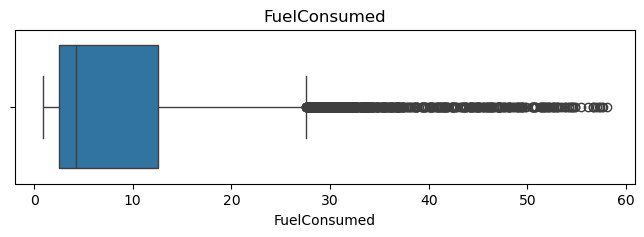

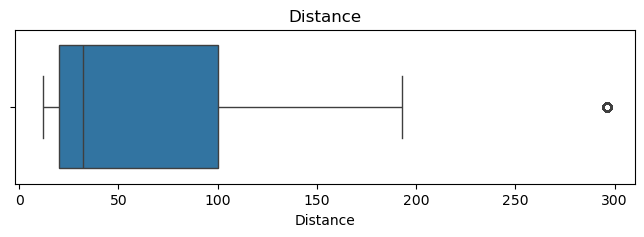

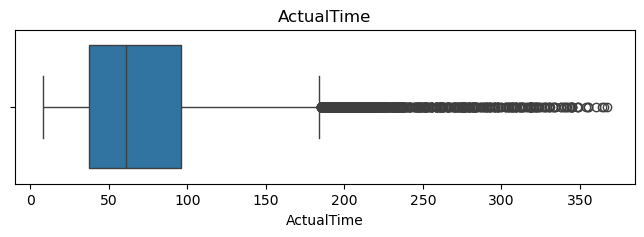

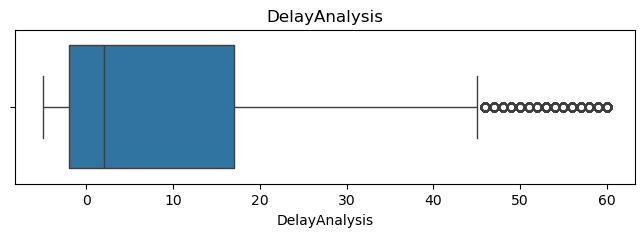

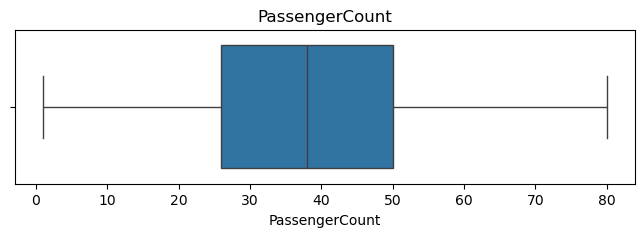

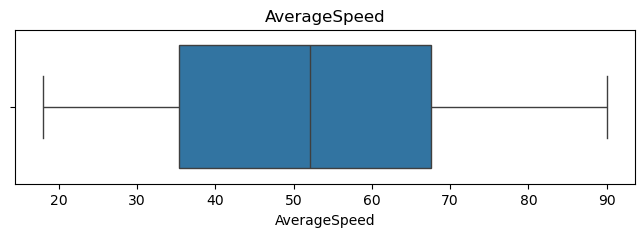

In [12]:
num_cols = [
    'FuelConsumed',
    'Distance',
    'ActualTime',
    'DelayAnalysis',
    'PassengerCount',
    'AverageSpeed'
]

for col in num_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=fact[col])

    plt.title(col)

    plt.show()